In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bali-tourist-attractions-dataset-from-google-maps/dataset_tempat_wisata_bali_cleaned.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import folium
from folium.plugins import MarkerCluster

In [3]:
df = pd.read_csv("/kaggle/input/bali-tourist-attractions-dataset-from-google-maps/dataset_tempat_wisata_bali_cleaned.csv")

In [4]:
df.head()

,nama,kategori,kabupaten_kota,rating,preferensi,link_lokasi,latitude,longitude,link_gambar
0,Taman Mumbul Sangeh,Alam,Kabupaten Badung,4.6,Wisata Alam,https://www.google.com/maps/place/Taman+Mumbul...,-8.483959,115.212288,https://lh3.googleusercontent.com/p/AF1QipPniB...
1,Sangeh Monkey Forest,Alam,Kabupaten Badung,4.6,Wisata Alam,https://www.google.com/maps/place/Sangeh+Monke...,-8.481774,115.206739,https://lh3.googleusercontent.com/p/AF1QipN2_T...
2,Objek Wisata Sangeh,Umum,Kabupaten Badung,4.6,Wisata Umum,https://www.google.com/maps/place/Objek+Wisata...,-8.481566,115.206546,https://lh3.googleusercontent.com/p/AF1QipO1t7...
3,Satria Gatotkaca Park,Umum,Kabupaten Badung,4.6,Wisata Umum,https://www.google.com/maps/place/Satria+Gatot...,-8.744388,115.178867,https://lh3.googleusercontent.com/p/AF1QipP3kd...
4,Desa Wisata Penarungan,Umum,Kabupaten Badung,5.0,Wisata Umum,https://www.google.com/maps/place/Desa+Wisata+...,-8.539637,115.198893,https://lh3.googleusercontent.com/p/AF1QipO-JZ...


In [5]:
df.isnull().sum()

nama              0
kategori          0
kabupaten_kota    0
rating            0
preferensi        0
link_lokasi       0
latitude          0
longitude         0
link_gambar       0
dtype: int64

In [6]:
# Normalize text: lowercase and strip whitespace for consistency
df['kategori'] = df['kategori'].str.strip().str.lower()
df['preferensi'] = df['preferensi'].str.strip().str.lower()
df['kabupaten_kota'] = df['kabupaten_kota'].str.strip().str.title()

In [7]:
# Set style
sns.set(style="whitegrid")

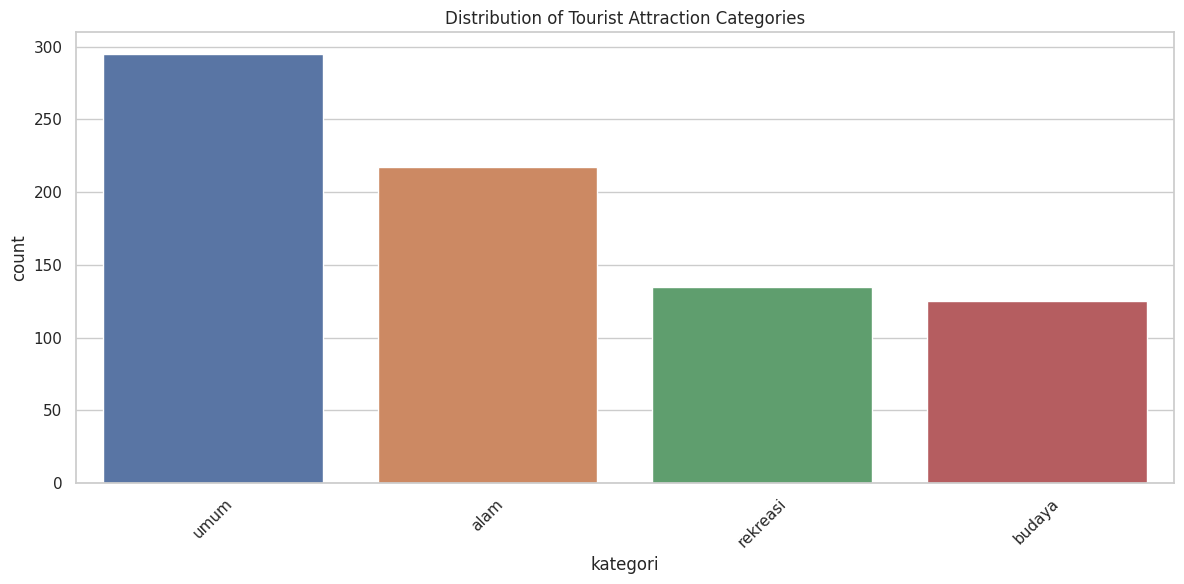

In [8]:
# Plot distribution of categories
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='kategori', order=df['kategori'].value_counts().index)
plt.title("Distribution of Tourist Attraction Categories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

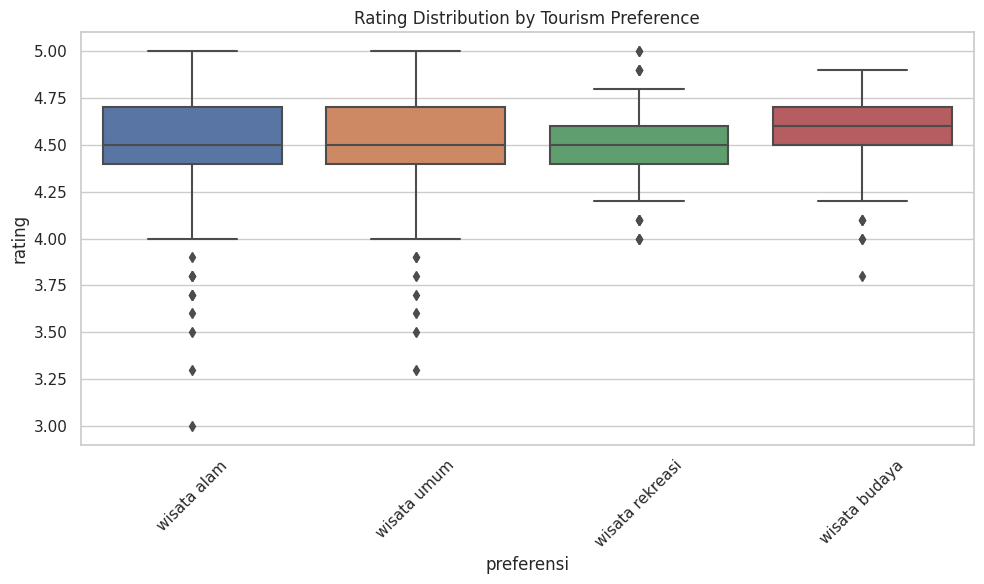

In [9]:
# Plot average rating by tourism preference
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='preferensi', y='rating')
plt.title("Rating Distribution by Tourism Preference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Top 10 rated places
top_rated = df.sort_values(by='rating', ascending=False).head(10)
print("\nTop 10 Tourist Attractions by Rating:")
print(top_rated[['nama', 'rating', 'kabupaten_kota', 'preferensi']])


Top 10 Tourist Attractions by Rating:
                                            nama  rating  \
453                         Di kaki Gunung Agung     5.0   
729  DERMAGA 2 WISATA PERAHU TAMAN PANCING TIMUR     5.0   
492                            West Garden Pangi     5.0   
228                      Kubu Ngurah Arsa アルサマヨン     5.0   
343                           MADU AMERTA BHUANA     5.0   
499               Obyek Wisata Batu Belah Antiga     5.0   
500                           Pondok Bukit Samuh     5.0   
54                             Taman desa Dalung     5.0   
57                       Sastra Bali Tour & Taxi     5.0   
65                                    Kedonganan     5.0   

           kabupaten_kota   preferensi  
453  Kabupaten Karangasem  wisata alam  
729         Kota Denpasar  wisata alam  
492  Kabupaten Karangasem  wisata umum  
228    Kabupaten Buleleng  wisata umum  
343     Kabupaten Gianyar  wisata umum  
499  Kabupaten Karangasem  wisata umum  
500  Kabupate